**REGRESSION PROBLEM**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Student Social Media And Mental Health Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [3]:
df.shape

(5000, 13)

In [4]:
df = df.drop_duplicates()

In [5]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

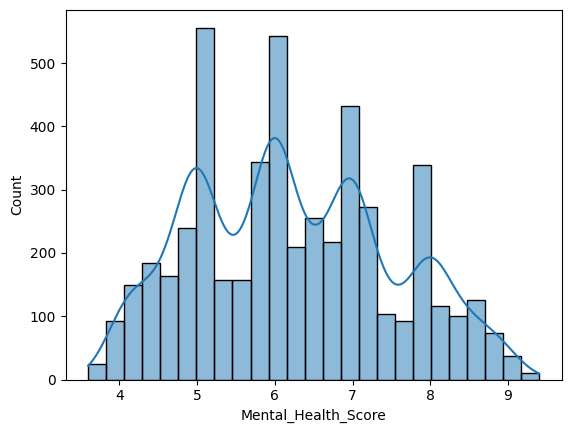

In [6]:
sns.histplot(df['Mental_Health_Score'],kde=True)

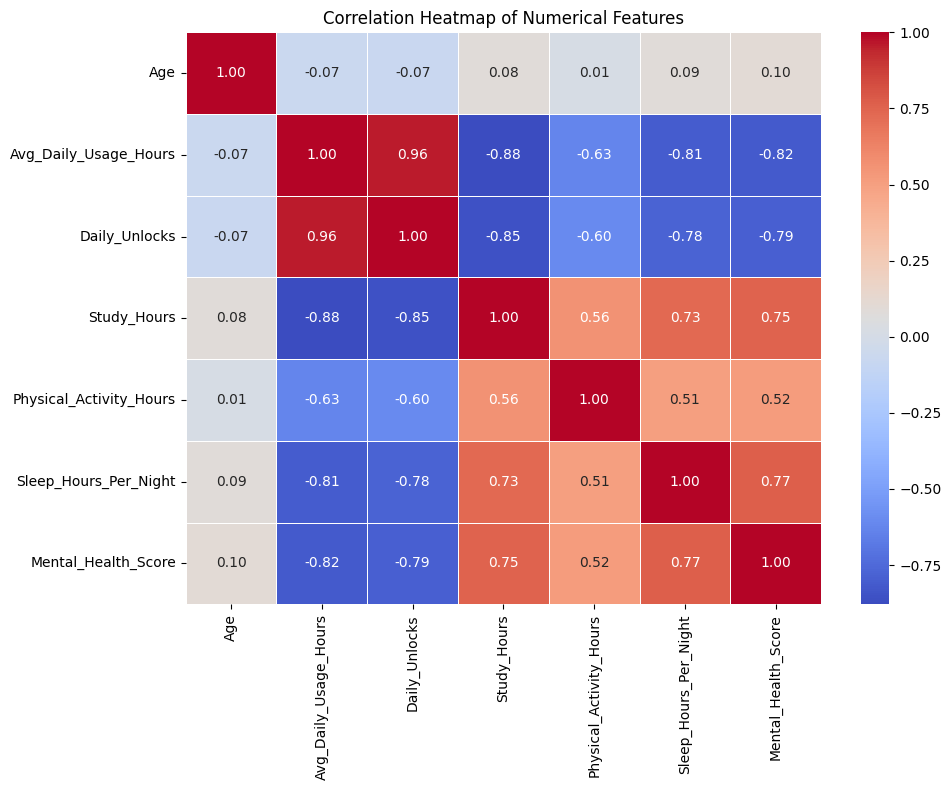

In [7]:

# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numerical_cols].corr()

# Generate the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2246/213697923.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=present_levels, palette='coolwarm')


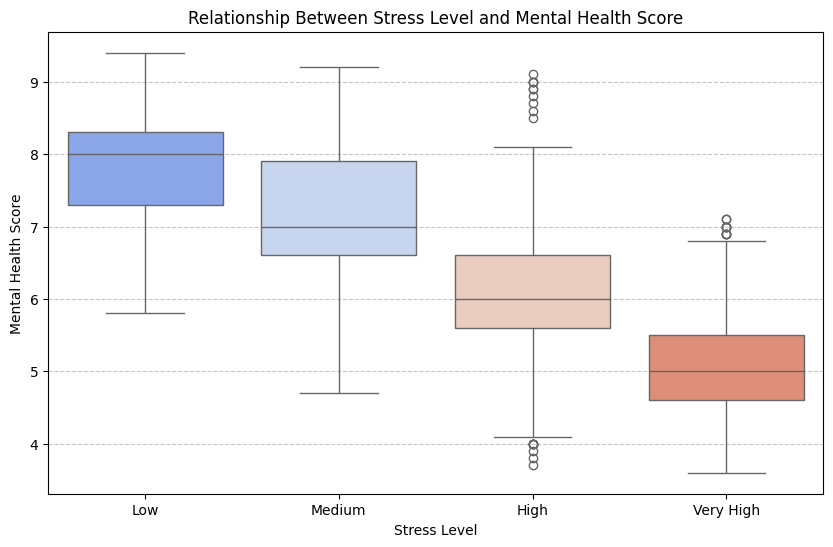

In [8]:
# Order stress levels logically from Low to Very High if present in dataset
stress_order = ['Low', 'Medium', 'High', 'Very High']
present_levels = [level for level in stress_order if level in df['Stress_Level'].unique()]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=present_levels, palette='coolwarm')
plt.title('Relationship Between Stress Level and Mental Health Score')
plt.xlabel('Stress Level')
plt.ylabel('Mental Health Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

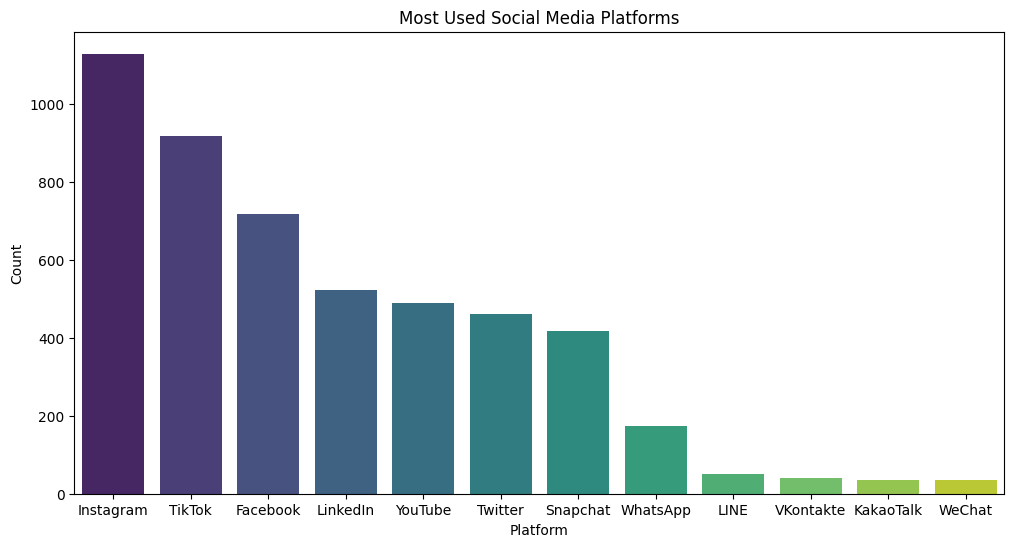

In [9]:
a = df['Most_Used_Platform'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=a.index, y=a.values, hue=a.index, palette='viridis', legend=False)
plt.title('Most Used Social Media Platforms')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.show()

**Checking Outlier**

In [10]:
num_fearture=df.select_dtypes(include='number')
Q1 = num_fearture.quantile(0.25)
Q3 = num_fearture.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outlier = (num_fearture < lower_bound) | (num_fearture > upper_bound)

print(outlier.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [11]:
#  Handling the negative value
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [12]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [14]:
from sklearn.model_selection import train_test_split

skwewd_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level',"Academic_Level"]
normal_col         = ["Gender","Most_Used_Platform", "Purpose_Of_Use"]

feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

**making pipeline**

In [17]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
# Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])

# Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

# Ordinal
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[
        ['Low', 'Medium', 'High', 'Very High'],
        ['High School', 'Undergraduate', 'Graduate']
    ]))
])

# Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])


# (konsi_pipeline, konsa_feature)
preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skwewd_col),
    ("Plain_Numeric",plain_numeric_pipeline, other_numeric_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', nominal_pipeline, normal_col)
])


**MODEL BUILDING**

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Create the final pipeline combining preprocessing and model
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit the model on training data
lr_model.fit(X_train, y_train)

# Predict on training and testing data
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Calculate metrics for training set
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

# Calculate metrics for testing set
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

# Display the results
print("=== Training Metrics ===")
print(f"R-squared (Accuracy): {train_r2:.4f}")
print(f"Mean Squared Error:    {train_mse:.4f}")
print(f"RMSE:                  {train_rmse:.4f}\n")

print("=== Testing Metrics ===")
print(f"R-squared (Accuracy): {test_r2:.4f}")
print(f"Mean Squared Error:    {test_mse:.4f}")
print(f"RMSE:                  {test_rmse:.4f}")

=== Training Metrics ===
R-squared (Accuracy): 0.7135
Mean Squared Error:    0.4529
RMSE:                  0.6730

=== Testing Metrics ===
R-squared (Accuracy): 0.7345
Mean Squared Error:    0.4663
RMSE:                  0.6829


In [19]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])

# Fit the Random Forest model
rf_pipeline.fit(X_train, y_train)

# Predict on training and testing sets
y_train_pred_rf = rf_pipeline.predict(X_train)
y_test_pred_rf = rf_pipeline.predict(X_test)

# Calculate metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("=== Random Forest Training Metrics ===")
print(f"R-squared (Accuracy): {train_r2_rf:.4f}")
print(f"RMSE:                  {train_rmse_rf:.4f}\n")

print("=== Random Forest Testing Metrics ===")
print(f"R-squared (Accuracy): {test_r2_rf:.4f}")
print(f"RMSE:                  {test_rmse_rf:.4f}")

=== Random Forest Training Metrics ===
R-squared (Accuracy): 0.9796
RMSE:                  0.1797

=== Random Forest Testing Metrics ===
R-squared (Accuracy): 0.8659
RMSE:                  0.4853


In [20]:
import joblib
joblib.dump(rf_pipeline,"Mental_health_model.pkl")

['Mental_health_model.pkl']